In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [3]:
X.shape

(1000, 2)

In [4]:
y.shape

(1000,)

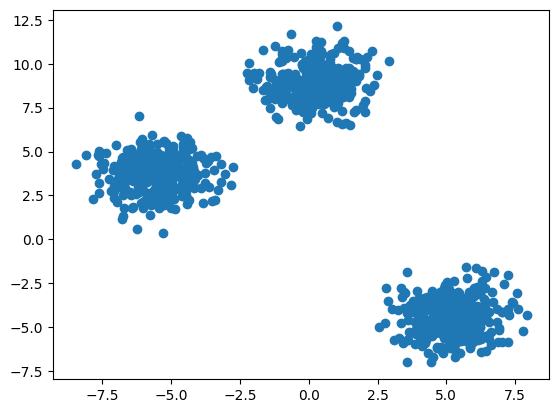

In [5]:
plt.scatter(X[:,0],X[:,1])

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train,y_train,X_test,y_test=train_test_split(X, y,test_size=0.33, random_state=42)

In [8]:
from sklearn.cluster import KMeans

In [9]:
#manual way 
#Elblow method to select the K value
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)


In [10]:
wcss

[34827.57682552022,
 7935.4372861454185,
 1319.2730531585607,
 1170.6952432118364,
 992.6978843650659,
 902.2605948257352,
 825.6795379274383,
 679.6297975802901,
 637.4476742591862,
 536.6709866904118]

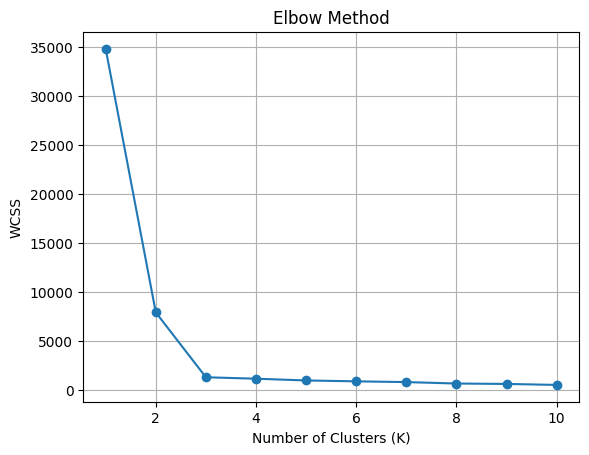

In [11]:
# Plot the Elbow Curve
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [12]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [13]:
y_lables=kmeans.fit_predict(X_train)

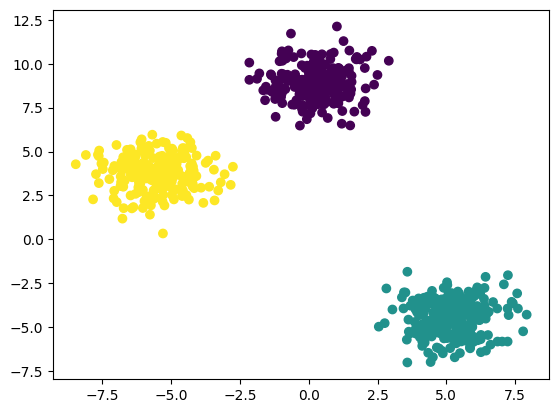

In [14]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_lables)

#we can see that we had found no. of cluster i.e 3 by manual method which generally for samll data sets 

In [15]:
!pip install kneed  


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#for automaticaly finding the value of k 
from kneed import KneeLocator

In [17]:
kl= KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [18]:
from sklearn.metrics import silhouette_score

silhouette_coefficients = []

# Test k from 2 to 10
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficients.append(score)





In [19]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6357733426488265),
 np.float64(0.4723297879921876),
 np.float64(0.33367872107343594),
 np.float64(0.32758752735600283),
 np.float64(0.33049705268923796),
 np.float64(0.3233874690312625),
 np.float64(0.32630032779404855)]

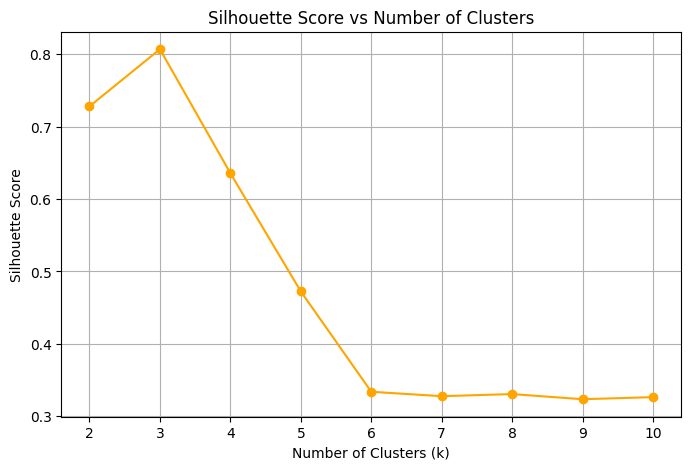

In [20]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_coefficients, marker='o', color='orange')
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()